In [1]:
from datamodel import TradingState, Listing, OrderDepth, Observation, Symbol, Trade, Position, Order
from backtester import Backtester
from typing import Dict, List
from trader import Trader
import matplotlib.pyplot as plt
from visualizer import BacktestingResult
import numpy as np
import json

In [3]:
from data_parser import clean_df
import pandas as pd
import matplotlib.pyplot as plt
df=clean_df(pd.read_csv("./data/round_1_data/prices_prosperity_3.csv"))

In [4]:
df.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,SQUID_INK,2005,1,2002,31,0,0,2006,31,0,0,0,0,2005.5,0.0
1,-1,0,RAINFOREST_RESIN,10002,1,9996,2,9995,29,10004,2,10005,29,0,0,10003.0,0.0
2,-1,0,KELP,2028,1,2026,2,2025,29,2029,31,0,0,0,0,2028.5,0.0
3,-1,100,KELP,2025,24,0,0,0,0,2028,2,2029,22,0,0,2026.5,0.0
4,-1,100,RAINFOREST_RESIN,9996,2,9995,22,0,0,10004,2,10005,22,0,0,10000.0,0.0


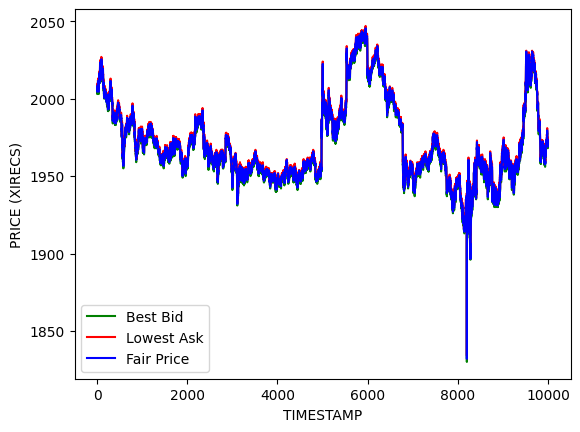

In [5]:
#TOMATOES RESEARCH

tomatoes_bid_price = df.loc[df['product']=="SQUID_INK"]["bid_price_1"].to_numpy()
tomatoes_ask_price = df.loc[df['product']=="SQUID_INK"]["ask_price_1"].to_numpy()
tomatoes_mid_price = df.loc[df['product']=="SQUID_INK"]["mid_price"].to_numpy().astype(float)

plt.plot([i for i in range(len(tomatoes_bid_price))], tomatoes_bid_price, color="green", label="Best Bid")
plt.plot([i for i in range(len(tomatoes_bid_price))], tomatoes_ask_price, color="red", label="Lowest Ask")
plt.plot([i for i in range(len(tomatoes_bid_price))], tomatoes_mid_price, color="blue", label="Fair Price")
plt.legend()
plt.xlabel("TIMESTAMP")
plt.ylabel("PRICE (XIRECS)")
plt.show()

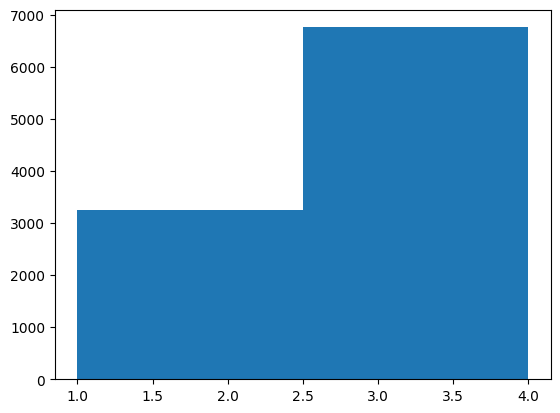

In [6]:
# Get the spread of tomatoes
plt.hist(tomatoes_ask_price-tomatoes_bid_price, bins=2)
plt.show()

In [51]:
import json
from datamodel import OrderDepth, TradingState, Order
from typing import Dict, List




class UserTrader(Trader):
    def __init__(self):
        self.alpha = 0.2 # EMA SMOOTH
    def get_weighted_liquidity(self, state: TradingState, symbol: str):
        weighted_bid = 0
        weighted_ask = 0

        volume_sum_bids=0
        volume_sum_asks=0

        for price in state.order_depths[symbol].buy_orders:
            weighted_bid+=(price*state.order_depths[symbol].buy_orders[price])
            volume_sum_bids+=state.order_depths[symbol].buy_orders[price]
        for price in state.order_depths[symbol].sell_orders:
            weighted_ask+=(price*abs(state.order_depths[symbol].sell_orders[price]))
            volume_sum_asks+=abs(state.order_depths[symbol].sell_orders[price])
        weighted_bid/=volume_sum_bids
        weighted_ask/=volume_sum_asks
        
        return (weighted_bid+weighted_ask)/2

    
    def trade_elemeralds(self, state: TradingState):
        symbol_name: str = "RAINFOREST_RESIN"
        LIMIT = 50
        position = state.position.get(symbol_name, 0)
        if position >= LIMIT: # flatten position to 0
           self.result[symbol_name].append(Order(symbol_name, 10000, -state.position[symbol_name]))
           return
        elif position <= -LIMIT: # flatten position to 0
           self.result[symbol_name].append(Order(symbol_name, 10000, abs(state.position[symbol_name])))
           return 
        
        best_bid = max(state.order_depths[symbol_name].buy_orders)
        best_ask = min(state.order_depths[symbol_name].sell_orders)

        bid_quote = best_bid + 1
        ask_quote = best_ask - 1

        if bid_quote < 10000:
            self.result[symbol_name].append(Order(symbol_name, bid_quote, min(LIMIT-position,(int((10000-bid_quote)/8 * 10)))))
        if ask_quote > 10000:
            self.result[symbol_name].append(Order(symbol_name, ask_quote, max(-LIMIT-position,-(int((ask_quote-10000)/8 * 10)))))
        

    def trade_tomatoes(self, state: TradingState):
        symbol_name: str = "KELP"
        LIMIT = 50
        position = state.position.get(symbol_name, 0)
        best_bid = max(state.order_depths[symbol_name].buy_orders)
        best_ask = min(state.order_depths[symbol_name].sell_orders)
        mp = int((best_bid+best_ask)/2)
        if position >= LIMIT: # flatten position to 0
           self.result[symbol_name].append(Order(symbol_name, mp, -state.position[symbol_name]))
           return
        elif position <= -LIMIT: # flatten position to 0
           self.result[symbol_name].append(Order(symbol_name, mp, abs(state.position[symbol_name])))
           return 
        
        bid_quote = best_bid + 1
        ask_quote = best_ask - 1

        if bid_quote < mp and ask_quote > mp:
            self.result[symbol_name].append(Order(symbol_name, bid_quote, min(LIMIT-position,(int((mp-bid_quote)/8 * 10)))))
            self.result[symbol_name].append(Order(symbol_name, ask_quote, max(-LIMIT-position,-(int((ask_quote-mp)/8 * 10)))))
    def trade_ink(self, state: TradingState):
        symbol_name: str = "SQUID_INK"
        LIMIT = 50
        position = state.position.get(symbol_name, 0)
        best_bid = max(state.order_depths[symbol_name].buy_orders)
        best_ask = min(state.order_depths[symbol_name].sell_orders)
        mp = int((best_bid+best_ask)/2)
        if position >= LIMIT: # flatten position to 0
           self.result[symbol_name].append(Order(symbol_name, mp, -state.position[symbol_name]))
           return
        elif position <= -LIMIT: # flatten position to 0
           self.result[symbol_name].append(Order(symbol_name, mp, abs(state.position[symbol_name])))
           return 
        
        bid_quote = best_bid + 1
        ask_quote = best_ask - 1

        if bid_quote < mp and ask_quote > mp:
            self.result[symbol_name].append(Order(symbol_name, bid_quote, min(LIMIT-position,(int((mp-bid_quote)/8 * 10)))))
            self.result[symbol_name].append(Order(symbol_name, ask_quote, max(-LIMIT-position,-(int((ask_quote-mp)/8 * 10)))))

    def run(self, state: TradingState):
        # Reset result state
        self.result={}
        self.ink_symbol = "SQUID_INK"
        if state.traderData != "":
            self.j_data = json.loads(state.traderData)

            # Update Data
            mp = (max(state.order_depths[self.ink_symbol].buy_orders) + min(state.order_depths[self.ink_symbol].sell_orders)) / 2
            self.j_data[self.ink_symbol+"_EMA"] = self.alpha * mp + (1 - self.alpha) * self.j_data[self.ink_symbol+"_EMA"]
            self.j_data[self.ink_symbol+"_MV"] = 0.8 * self.j_data[self.ink_symbol+"_MV"] + 0.2 * abs(mp - self.j_data[self.ink_symbol+"_EMA"])
            
        else:
            self.j_data = {
                self.ink_symbol+"_EMA": (max(state.order_depths[self.ink_symbol].buy_orders) + min(state.order_depths[self.ink_symbol].sell_orders)) / 2,
                self.ink_symbol+"_MV": 1
            }
        self.result["RAINFOREST_RESIN"]=[]
        self.result["KELP"]=[]
        self.result[self.ink_symbol]=[]
        # Call Trading Functions
        #self.trade_elemeralds(state)
        #self.trade_tomatoes(state)
        self.trade_ink(state)
        return self.result, 0, json.dumps(self.j_data)

In [7]:
backtesting_engine = Backtester("./data/round_1_data/prices_prosperity_3.csv", "./data/round_1_data/trades_prosperity_3.csv")

c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("", 0)
c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["buyer"].replace(0, "", inplace=True)
c:\Project

In [63]:
sample_trader = UserTrader()
backtesting_engine.custom_shifter["KELP"]=1.5
backtesting_engine.custom_shifter["SQUID_INK"]=0.5
backtesting_result = backtesting_engine.run_trader(sample_trader, enable_probabilistic_fills=True, enable_market_trades=False)

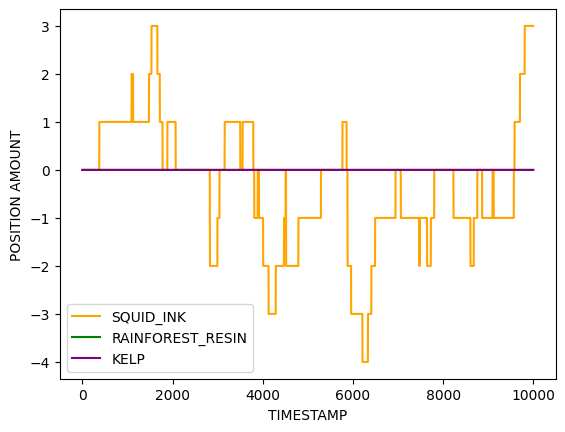

In [64]:
backtesting_result.graph_inventory()

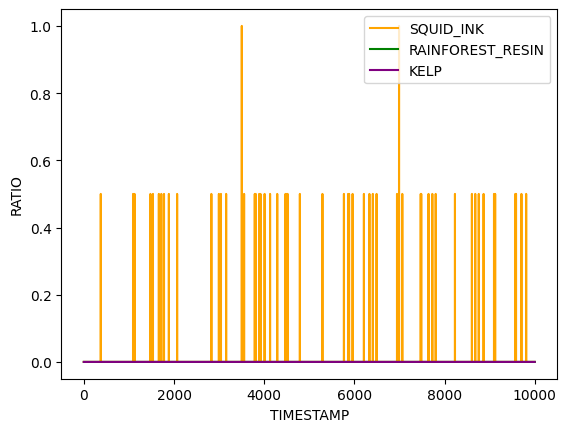

In [65]:
backtesting_result.graph_fill_ratios()

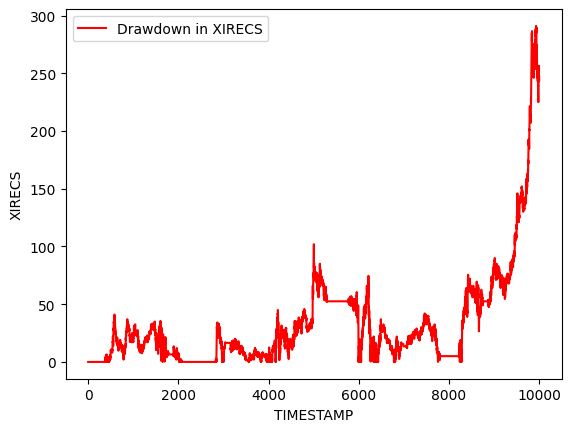

In [66]:
backtesting_result.graph_drawdown()

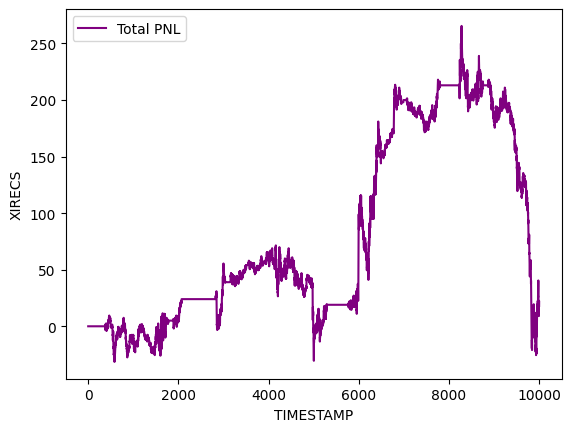

In [67]:
backtesting_result.graph_pnl()

In [31]:
import math

total_runs = 100
all_end_pnl=[]
all_sharpe=[]
for i in range(total_runs):
    backtesting_result = backtesting_engine.run_trader(sample_trader, enable_probabilistic_fills=True)
    t_sum = 0
    total_pnl_series=[]
    for symbol in backtesting_engine.symbols:
        t_sum+=backtesting_result.pnl_realized[len(backtesting_result.pnl_realized)-1][symbol]
        t_sum+=backtesting_result.pnl_unrealized[len(backtesting_result.pnl_realized)-1][symbol]

    for t in range(len(backtesting_result.pnl_realized)):
        s=0
        for symbol in backtesting_engine.symbols:
            s+=backtesting_result.pnl_realized[t][symbol]
            s+=backtesting_result.pnl_unrealized[t][symbol]
        total_pnl_series.append(s)

    returns = np.diff(total_pnl_series)
    mean_ret = returns.mean()
    std_ret = returns.std()
    all_sharpe.append((mean_ret/std_ret)*math.sqrt(len(backtesting_result.pnl_realized)))
    all_end_pnl.append(t_sum)



(array([ 5.,  4.,  7., 19., 17., 21., 16.,  7.,  2.,  2.]),
 array([4662. , 4794.6, 4927.2, 5059.8, 5192.4, 5325. , 5457.6, 5590.2,
        5722.8, 5855.4, 5988. ]),
 <BarContainer object of 10 artists>)

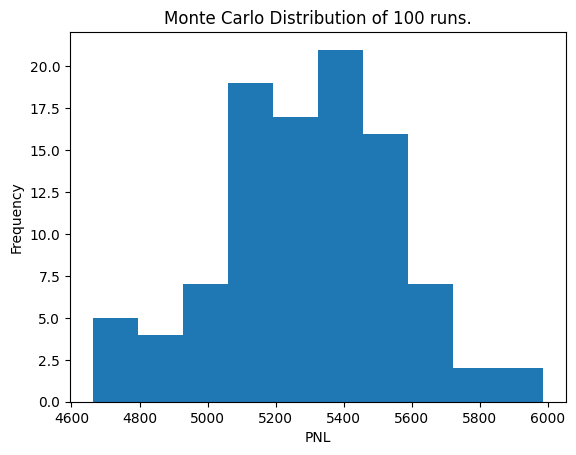

In [32]:
#plt.hist(all_sharpe, bins=10)
plt.title("Monte Carlo Distribution of " + str(total_runs) + " runs.")
plt.xlabel("PNL")
plt.ylabel("Frequency")
plt.hist(all_end_pnl, bins=10)

(array([ 7.,  8., 12., 15., 12., 16., 13.,  6.,  8.,  3.]),
 array([1.46392817, 2.12007765, 2.77622714, 3.43237663, 4.08852612,
        4.74467561, 5.4008251 , 6.05697459, 6.71312408, 7.36927357,
        8.02542305]),
 <BarContainer object of 10 artists>)

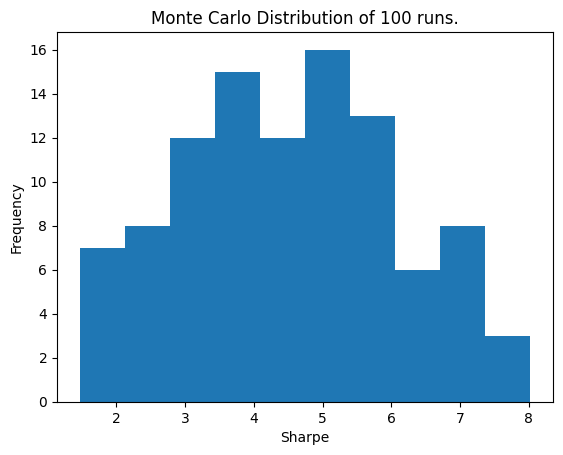

In [33]:
plt.title("Monte Carlo Distribution of " + str(total_runs) + " runs.")
plt.xlabel("Sharpe")
plt.ylabel("Frequency")
plt.hist(all_sharpe, bins=10)

In [34]:
# Print montecarlo sim stats
a_s = np.array(all_sharpe)
print ("Mean Sharpe: " + str(a_s.mean()))
print ("STD Sharpe: " + str(a_s.std()))

standard_error_sharpe = a_s.mean()/math.sqrt(len(all_sharpe))
target_z_score = 1.96

print ("95% Confidence that sharpe is between " + str(a_s.mean() - standard_error_sharpe*target_z_score) + " and " + str(a_s.mean() + standard_error_sharpe*target_z_score))

a_p = np.array(all_end_pnl)
print ("Mean PNL: " + str(a_p.mean()))
print ("STD PNL: " + str(a_p.std()))

standard_error_pnl = a_p.mean()/math.sqrt(len(all_end_pnl))
print ("95% Confidence that PNL is between " + str(a_p.mean() - standard_error_pnl*target_z_score) + " and " + str(a_p.mean() + standard_error_pnl*target_z_score))

Mean Sharpe: 4.510489667505426
STD Sharpe: 1.5841596141411087
95% Confidence that sharpe is between 3.6264336926743623 and 5.394545642336489
Mean PNL: 5293.805
STD PNL: 260.60514092204704
95% Confidence that PNL is between 4256.219220000001 and 6331.39078
